# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [1]:
import sys
print(sys.executable)

/Users/Benjamin/ai/projects/tinyml-arduino/bin/python


In [2]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [37]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [38]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

X = df.drop(columns=["Class"]).to_numpy(dtype=np.float32)
y = df["Class"].to_numpy(dtype=np.int32)



In [39]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (124, 13)
X_test shape: (54, 13)


In [40]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)


In [42]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

from tensorflow.keras import layers, Sequential

model = Sequential([
    layers.Dense(64, activation='relu', input_shape=(num_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                896       
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [43]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, 
    y_train_oh, 
    epochs=20, 
    batch_size=8, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
13/13 [==============================] - 0s 4ms/step - loss: 1.0671 - accuracy: 0.5253 - val_loss: 0.8755 - val_accuracy: 0.6800
Epoch 2/20
13/13 [==============================] - 0s 1ms/step - loss: 0.7528 - accuracy: 0.8889 - val_loss: 0.6082 - val_accuracy: 0.9200
Epoch 3/20
13/13 [==============================] - 0s 1ms/step - loss: 0.5366 - accuracy: 0.9495 - val_loss: 0.4187 - val_accuracy: 1.0000
Epoch 4/20
13/13 [==============================] - 0s 1ms/step - loss: 0.3691 - accuracy: 0.9596 - val_loss: 0.2868 - val_accuracy: 1.0000
Epoch 5/20
13/13 [==============================] - 0s 1ms/step - loss: 0.2482 - accuracy: 0.9899 - val_loss: 0.2023 - val_accuracy: 1.0000
Epoch 6/20
13/13 [==============================] - 0s 1ms/step - loss: 0.1720 - accuracy: 1.0000 - val_loss: 0.1469 - val_accuracy: 1.0000
Epoch 7/20
13/13 [==============================] - 0s 1ms/step - loss: 0.1243 - accuracy: 1.0000 - val_loss: 0.1110 - val_accuracy: 1.0000
Epoch 8/20
13/13 [==

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



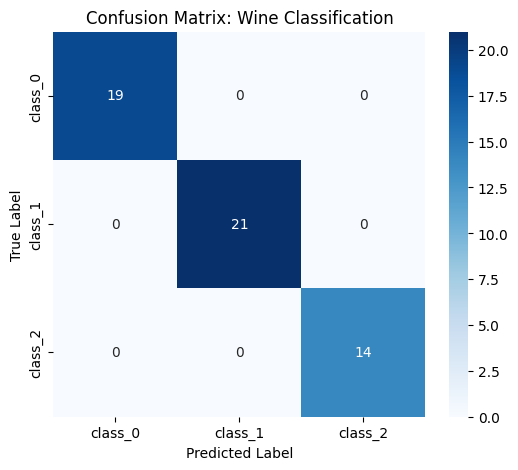

In [44]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

loss, accuracy = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}\n")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine.target_names, 
            yticklabels=wine.target_names)
plt.title('Confusion Matrix: Wine Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [45]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("model_base.tflite", "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"TFLite Model Size: {size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpdmossdk6/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpdmossdk6/assets


TFLite Model Size: 14.10 KB


2026-05-20 13:00:17.730689: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 13:00:17.730703: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 13:00:17.730786: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpdmossdk6
2026-05-20 13:00:17.731179: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 13:00:17.731182: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpdmossdk6
2026-05-20 13:00:17.732169: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 13:00:17.745294: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpdmossdk6
2026-05-

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [46]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]

        converter.representative_dataset = lambda: representative_data_gen(X_train)

        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
        pass

    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        converter.optimizations = [tf.lite.Optimize.DEFAULT]

        converter.target_spec.supported_types = [tf.float16]
        pass

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        pass

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.

    tflite_model = converter.convert()

    with open(filename, "wb") as f:
        f.write(tflite_model)

    size_kb = len(tflite_model) / 1024
    print(f"Successfully saved {filename} | Size: {size_kb:.2f} KB")
    
    

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_index = input_details['index']
    output_index = output_details['index']

    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = []

    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)

        if input_details['dtype'] == np.int8:
            scale, zero_point = input_details['quantization']
            sample = np.round(sample / scale + zero_point).astype(np.int8)
            
        interpreter.set_tensor(input_index, sample)
        interpreter.invoke()

        output = interpreter.get_tensor(output_index)

        if output_details['dtype'] == np.int8:
            scale, zero_point = output_details['quantization']
            output = (output.astype(np.float32) - zero_point) * scale

        y_pred.append(np.argmax(output))

    y_pred = np.array(y_pred)
    accuracy = np.mean(y_pred == y_true)
    print(f"Quantization Type: {quant_type} | Test Accuracy: {accuracy:.4f}")

    # Step 4: Report results.

    print(f"\nClassification Report ({quant_type.upper()} Model):")
    print(classification_report(y_true, y_pred, target_names=wine.target_names))

    print(f"Confusion Matrix ({quant_type.upper()} Model):")
    print(confusion_matrix(y_true, y_pred))
    print("-" * 50)
    
    return tflite_model

    


In [47]:
# Step 5: Use the function above to create and evaluate three quantized models:
# - 'int8' saved as 'model_int8.tflite'
# - 'float16' saved as 'model_float16.tflite'
# - 'dynamic' saved as 'model_dynamic.tflite'

acc_dynamic = quantize_and_evaluate(model, X_test, y_test_oh, 'dynamic', 'model_dynamic.tflite')

acc_float16 = quantize_and_evaluate(model, X_test, y_test_oh, 'float16', 'model_float16.tflite')

acc_int8 = quantize_and_evaluate(model, X_test, y_test_oh, 'int8', 'model_int8.tflite')


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt03rzm__/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt03rzm__/assets


Successfully saved model_dynamic.tflite | Size: 8.20 KB
Quantization Type: dynamic | Test Accuracy: 1.0000

Classification Report (DYNAMIC Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (DYNAMIC Model):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
--------------------------------------------------
INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp0xvfa3zl/assets


2026-05-20 13:00:19.606067: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 13:00:19.606077: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 13:00:19.606160: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt03rzm__
2026-05-20 13:00:19.606562: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 13:00:19.606565: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt03rzm__
2026-05-20 13:00:19.607493: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 13:00:19.620420: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpt03rzm__
2026-05-

Successfully saved model_float16.tflite | Size: 9.00 KB
Quantization Type: float16 | Test Accuracy: 1.0000

Classification Report (FLOAT16 Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (FLOAT16 Model):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
--------------------------------------------------
INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp66wjs0vj/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp66wjs0vj/assets


Successfully saved model_int8.tflite | Size: 5.76 KB
Quantization Type: int8 | Test Accuracy: 1.0000

Classification Report (INT8 Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (INT8 Model):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
--------------------------------------------------


/Users/Benjamin/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-20 13:00:20.106051: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 13:00:20.106060: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 13:00:20.106148: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp66wjs0vj
2026-05-20 13:00:20.106511: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 13:00:20.106514: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp66wjs0vj
2026-05-20 13:00:20.107448: I tensorflow/cc/saved_model/loader.cc:233]

## Problem 1 - Part (c)

### Pruning

In [48]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)


train_samples = len(X_train) * 0.8  
batch_size = 8
epochs = 20

steps_per_epoch = np.ceil(train_samples / batch_size)
total_training_steps = int(steps_per_epoch * epochs)

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.50,
    final_sparsity=0.70,
    begin_step=0,
    end_step=total_training_steps
)

print(f"Total training steps calculated for pruning: {total_training_steps}")

Total training steps calculated for pruning: 260


In [52]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

from tensorflow_model_optimization.sparsity.keras import prune_low_magnitude
pruned_model = Sequential([
    prune_low_magnitude(
        layers.Dense(64, activation='relu', input_shape=(num_features,)),
        pruning_schedule=pruning_schedule
    ),
    
    prune_low_magnitude(
        layers.Dense(32, activation='relu'),
        pruning_schedule=pruning_schedule
    ),
    
    prune_low_magnitude(
        layers.Dense(num_classes, activation='softmax'),
        pruning_schedule=pruning_schedule
    )
])

pruned_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 64)                1730      
 9 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                4130      
 10 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 3)                 197       
 11 (PruneLowMagnitude)                                          
                                                                 
Total params: 6057 (23.67 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 2982 (11.66 KB)
_________________________________________________________________


In [53]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

pruned_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

pruned_history = pruned_model.fit(
    X_train,
    y_train_oh,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
13/13 [==============================] - 1s 5ms/step - loss: 1.0959 - accuracy: 0.4343 - val_loss: 0.8835 - val_accuracy: 0.5600
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 0.7789 - accuracy: 0.7980 - val_loss: 0.6631 - val_accuracy: 0.8400
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 0.5722 - accuracy: 0.9192 - val_loss: 0.5013 - val_accuracy: 0.9600
Epoch 4/10
13/13 [==============================] - 0s 1ms/step - loss: 0.4195 - accuracy: 0.9596 - val_loss: 0.3788 - val_accuracy: 0.9600
Epoch 5/10
13/13 [==============================] - 0s 1ms/step - loss: 0.3039 - accuracy: 0.9697 - val_loss: 0.2888 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 1ms/step - loss: 0.2263 - accuracy: 0.9798 - val_loss: 0.2253 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 0.1711 - accuracy: 0.9798 - val_loss: 0.1809 - val_accuracy: 0.9600
Epoch 8/10
13/13 [==

In [54]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)

tflite_pruned_model = converter.convert()

filename_pruned = "model_pruned.tflite"
with open(filename_pruned, "wb") as f:
    f.write(tflite_pruned_model)

size_pruned_kb = len(tflite_pruned_model) / 1024
print(f"Pruned TFLite Model Size: {size_pruned_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp_olhas9y/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp_olhas9y/assets


Pruned TFLite Model Size: 14.16 KB


2026-05-20 13:02:49.257951: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 13:02:49.257967: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 13:02:49.258054: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp_olhas9y
2026-05-20 13:02:49.258354: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 13:02:49.258357: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp_olhas9y
2026-05-20 13:02:49.259004: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 13:02:49.265157: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmp_olhas9y
2026-05-

In [55]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

y_pred_probs_pruned = stripped_model.predict(X_test, verbose=0)
y_pred_pruned = np.argmax(y_pred_probs_pruned, axis=1)

y_true = np.argmax(y_test_oh, axis=1)

print("Pruned Model Classification Report:")
print(classification_report(y_true, y_pred_pruned, target_names=wine.target_names))

print("Pruned Model Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_pruned))

Pruned Model Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        14

    accuracy                           0.94        54
   macro avg       0.94      0.94      0.94        54
weighted avg       0.94      0.94      0.94        54

Pruned Model Confusion Matrix:
[[18  1  0]
 [ 0 20  1]
 [ 1  0 13]]


## Problem 1 - Part (d)

### Knowledge Distillation

In [56]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

student_model = Sequential([
    layers.Dense(32, activation='relu', input_shape=(num_features,)),
    
    layers.Dense(16, activation='relu'),
    
    layers.Dense(num_classes, activation='softmax')
])

student_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 32)                448       
                                                                 
 dense_13 (Dense)            (None, 16)                528       
                                                                 
 dense_14 (Dense)            (None, 3)                 51        
                                                                 
Total params: 1027 (4.01 KB)
Trainable params: 1027 (4.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [69]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

teacher_final_layer = model.layers[-1]
original_activation = teacher_final_layer.activation

teacher_final_layer.activation = None
teacher_train_logits = model.predict(X_train, verbose=0)

teacher_final_layer.activation = original_activation

print("Shape of Teacher Logits:", teacher_train_logits.shape)

Shape of Teacher Logits: (124, 3)


In [70]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels
import tensorflow as tf
import numpy as np

TEMPERATURE = 3.0
ALPHA = 0.5
exp_logits = np.exp(teacher_train_logits / TEMPERATURE)
teacher_preds_soft = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# 2. Concatenate hard labels (columns 0-2) and soft labels (columns 3-5) along axis=1
y_train_combined = np.concatenate([y_train_oh, teacher_preds_soft], axis=1)

print("Shape of y_train_combined:", y_train_combined.shape)  # Verifies as (124, 6)

def distillation_loss(y_true_combined, y_pred):

    y_true_hard = y_true_combined[:, :3]
    y_true_soft = y_true_combined[:, 3:]
    
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)
    
    weighted_loss = (ALPHA * hard_loss) + ((1.0 - ALPHA) * (TEMPERATURE ** 2) * soft_loss)
    
    return weighted_loss
    pass

Shape of y_train_combined: (124, 6)


In [71]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

student_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=distillation_loss,
    metrics=['accuracy']
)

student_history = student_model.fit(
    X_train,
    y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
13/13 [==============================] - 0s 4ms/step - loss: 5.6245 - accuracy: 0.5051 - val_loss: 5.5377 - val_accuracy: 0.6000
Epoch 2/10
13/13 [==============================] - 0s 1ms/step - loss: 5.5148 - accuracy: 0.5859 - val_loss: 5.4692 - val_accuracy: 0.6400
Epoch 3/10
13/13 [==============================] - 0s 1ms/step - loss: 5.4545 - accuracy: 0.6869 - val_loss: 5.4481 - val_accuracy: 0.7200
Epoch 4/10
13/13 [==============================] - 0s 1ms/step - loss: 5.4241 - accuracy: 0.7374 - val_loss: 5.4169 - val_accuracy: 0.7600
Epoch 5/10
13/13 [==============================] - 0s 1ms/step - loss: 5.4000 - accuracy: 0.8182 - val_loss: 5.4041 - val_accuracy: 0.8400
Epoch 6/10
13/13 [==============================] - 0s 1ms/step - loss: 5.3860 - accuracy: 0.8687 - val_loss: 5.3999 - val_accuracy: 0.9200
Epoch 7/10
13/13 [==============================] - 0s 1ms/step - loss: 5.3731 - accuracy: 0.8889 - val_loss: 5.3888 - val_accuracy: 0.9200
Epoch 8/10
13/13 [==

In [72]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

converter = tf.lite.TFLiteConverter.from_keras_model(student_model)

tflite_kd_model = converter.convert()

filename_kd = "model_kd.tflite"
with open(filename_kd, "wb") as f:
    f.write(tflite_kd_model)

size_kd_kb = len(tflite_kd_model) / 1024
print(f"Distilled Student TFLite Model Size: {size_kd_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpjt_e6lsj/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpjt_e6lsj/assets


Distilled Student TFLite Model Size: 6.14 KB


2026-05-20 13:14:33.658724: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 13:14:33.658745: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 13:14:33.658824: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpjt_e6lsj
2026-05-20 13:14:33.659157: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 13:14:33.659160: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpjt_e6lsj
2026-05-20 13:14:33.660092: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-20 13:14:33.673427: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpjt_e6lsj
2026-05-

In [73]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix


y_pred_probs_student = student_model.predict(X_test, verbose=0)
y_pred_student = np.argmax(y_pred_probs_student, axis=1)

y_true = np.argmax(y_test_oh, axis=1)

print("Distilled Student Model Classification Report:")
print(classification_report(y_true, y_pred_student, target_names=wine.target_names))

print("Distilled Student Model Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_student))

Distilled Student Model Classification Report:
              precision    recall  f1-score   support

     class_0       0.88      0.79      0.83        19
     class_1       0.90      0.90      0.90        21
     class_2       0.81      0.93      0.87        14

    accuracy                           0.87        54
   macro avg       0.87      0.87      0.87        54
weighted avg       0.87      0.87      0.87        54

Distilled Student Model Confusion Matrix:
[[15  1  3]
 [ 2 19  0]
 [ 0  1 13]]


## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


In [77]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Redefine the Student Architecture
combined_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(y_train_oh.shape[1], activation='softmax')
])

# Setup Pruning Schedule for the Student
train_samples = len(X_train) * 0.8
batch_size = 8
epochs = 10
steps_per_epoch = np.ceil(train_samples / batch_size)
total_steps = int(steps_per_epoch * epochs)

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.50,
    final_sparsity=0.70,
    begin_step=0,
    end_step=total_steps
)

# Apply Pruning Wrappers to the Student
pruned_student = tf.keras.Sequential([
    tfmot.sparsity.keras.prune_low_magnitude(combined_model.layers[0], pruning_schedule=pruning_schedule),
    tfmot.sparsity.keras.prune_low_magnitude(combined_model.layers[1], pruning_schedule=pruning_schedule),
    tfmot.sparsity.keras.prune_low_magnitude(combined_model.layers[2], pruning_schedule=pruning_schedule)
])

# Compile and Fit using the Distillation Loss from Part (d)
pruned_student.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
    loss=distillation_loss,
    metrics=['accuracy']
)

pruned_student.fit(
    X_train,
    y_train_combined,
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=0
)

# Strip Pruning Wrappers
stripped_student = tfmot.sparsity.keras.strip_pruning(pruned_student)

# Convert with Full INT8 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = lambda: representative_data_gen(X_train)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_ultimate_model = converter.convert()

# Save and Measure Size
filename_ultimate = "model_ultimate.tflite"
with open(filename_ultimate, "wb") as f:
    f.write(tflite_ultimate_model)

size_ultimate_kb = len(tflite_ultimate_model) / 1024
print(f"Ultimate Optimized Model Size: {size_ultimate_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpumt2c3pz/assets


INFO:tensorflow:Assets written to: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpumt2c3pz/assets


Ultimate Optimized Model Size: 5.84 KB


/Users/Benjamin/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-20 14:56:59.905354: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-20 14:56:59.905374: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-20 14:56:59.905491: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpumt2c3pz
2026-05-20 14:56:59.905821: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-20 14:56:59.905825: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/zv/1cyb1zfx2wj7mthm8xx9nmqc0000gn/T/tmpumt2c3pz
2026-05-20 14:56:59.906593: I tensorflow/cc/saved_model/loader.cc:233]

In [79]:
# Run TFLite Inference on the Ultimate Model
interpreter = tf.lite.Interpreter(model_content=tflite_ultimate_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
input_index = input_details['index']
output_index = output_details['index']

y_true = np.argmax(y_test_oh, axis=1)
y_pred = []

for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    
    # Handle INT8 Input Quantization
    if input_details['dtype'] == np.int8:
        scale, zero_point = input_details['quantization']
        sample = np.round(sample / scale + zero_point).astype(np.int8)
        
    interpreter.set_tensor(input_index, sample)
    interpreter.invoke()
    
    output = interpreter.get_tensor(output_index)
    
    # Handle INT8 Output Dequantization
    if output_details['dtype'] == np.int8:
        scale, zero_point = output_details['quantization']
        output = (output.astype(np.float32) - zero_point) * scale
        
    y_pred.append(np.argmax(output))

y_pred = np.array(y_pred)
accuracy = np.mean(y_pred == y_true)

print(f"\nUltimate Model Test Accuracy: {accuracy:.4f}")
print("\nClassification Report (Ultimate Model):")
print(classification_report(y_true, y_pred, target_names=wine.target_names))


Ultimate Model Test Accuracy: 0.9444

Classification Report (Ultimate Model):
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        14

    accuracy                           0.94        54
   macro avg       0.94      0.94      0.94        54
weighted avg       0.94      0.94      0.94        54



# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
